GLOBALNE IMPORTY I FUNKCJE POMOCNICZE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid")

def plot_learning_curves(history, metric_name='accuracy'):

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Trening (Loss)', color='blue', lw=2)
    plt.plot(history.history['val_loss'], label='Walidacja (Loss)', color='orange', linestyle='--', lw=2)
    plt.title('Krzywa Straty (Loss)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoki', fontsize=12)
    plt.ylabel('Wartość straty', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history[metric_name], label=f'Trening ({metric_name})', color='blue', lw=2)
    plt.plot(history.history[f'val_{metric_name}'], label=f'Walidacja ({metric_name})', color='orange', linestyle='--', lw=2)
    plt.title(f'Krzywa Metryki ({metric_name.upper()})', fontsize=14, fontweight='bold')
    plt.xlabel('Epoki', fontsize=12)
    plt.ylabel(metric_name.capitalize(), fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, cbar=False,
                annot_kws={"size": 12, "weight": "bold"})
    plt.title('Macierz Pomyłek (Confusion Matrix)', fontsize=14, fontweight='bold')
    plt.ylabel('Klasa Rzeczywista', fontsize=12)
    plt.xlabel('Klasa Przewidziana', fontsize=12)
    plt.tight_layout()
    plt.show()

I0000 00:00:1781166519.531601   24876 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781166519.532085   24876 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781166519.576937   24876 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781166520.525082   24876 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

PRZYGOTOWANIE I FILTROWANIE DANYCH WEJŚCIOWYCH


In [ ]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar100.load_data()

selected_classes = [8, 13, 48, 58, 90]
class_names_c100 = ['Bicycle', 'Bus', 'Motorcycle', 'Pickup', 'Train']

train_mask = np.isin(y_train_full, selected_classes).flatten()
test_mask = np.isin(y_test_full, selected_classes).flatten()

x_train_c100 = x_train_full[train_mask].astype("float32") / 255.0
x_test_c100 = x_test_full[test_mask].astype("float32") / 255.0

mapping = {old_id: new_id for new_id, old_id in enumerate(selected_classes)}
y_train_c100 = np.array([mapping[cls] for cls in y_train_full[train_mask].flatten()])
y_test_c100 = np.array([mapping[cls] for cls in y_test_full[test_mask].flatten()])

url_wine = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df_wine = pd.read_csv(url_wine, sep=';')

X_wine = df_wine.drop(columns=['quality']).values

y_wine = (df_wine['quality'] >= 6).astype(int).values

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)

scaler_wine = StandardScaler()
X_train_w = scaler_wine.fit_transform(X_train_w)
X_test_w = scaler_wine.transform(X_test_w)

print("Status: Wszystkie zbiory danych zostały załadowane i poprawnie przetworzone.")

/home/uzytkownik/jupyter-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Status: Wszystkie zbiory danych zostały załadowane i poprawnie przetworzone.


ZADANIE 1: CIFAR-100 (CONVOLUTIONAL NEURAL NETWORK)


--- WIZUALIZACJA LOSOWYCH ZDJĘĆ Z WYBRANYCH KLAS ---


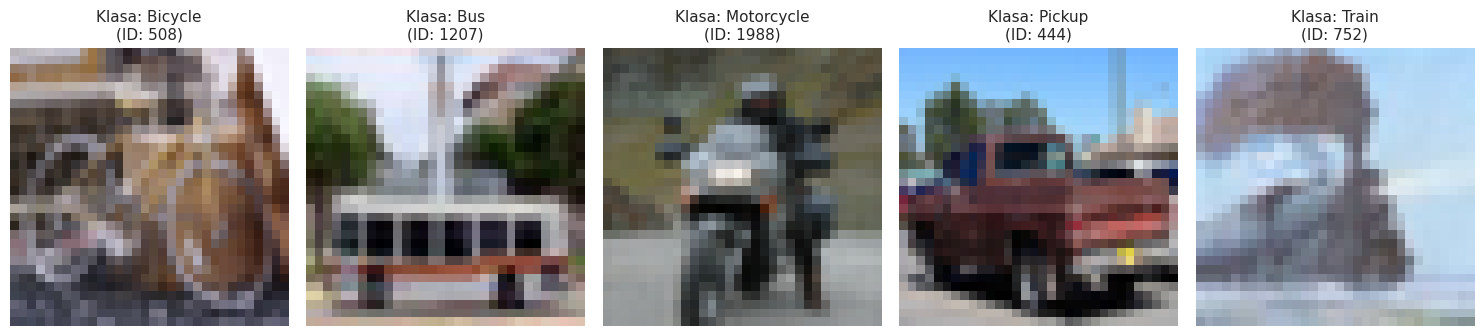


--- INICJALIZACJA ARCHITEKTURY I TRENINGU MODELU CNN ---


E0000 00:00:1781166523.332410   24876 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781166523.352020   24876 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.3680 - loss: 2.0393 - val_accuracy: 0.1580 - val_loss: 2.0718
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.4690 - loss: 1.6261 - val_accuracy: 0.1580 - val_loss: 2.9535
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5055 - loss: 1.4273 - val_accuracy: 0.1580 - val_loss: 3.2768
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5330 - loss: 1.3087 - val_accuracy: 0.2200 - val_loss: 3.5011
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5580 - loss: 1.2429 - val_accuracy: 0.2420 - val_loss: 3.4866
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5485 - loss: 1.2043 - val_accuracy: 0.2120 - val_loss: 4.2172
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5895 - loss: 1.1378 - val_accuracy: 0.2480 - val_loss: 4.0547
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5950 - loss: 1.1036 - val_accuracy: 0.

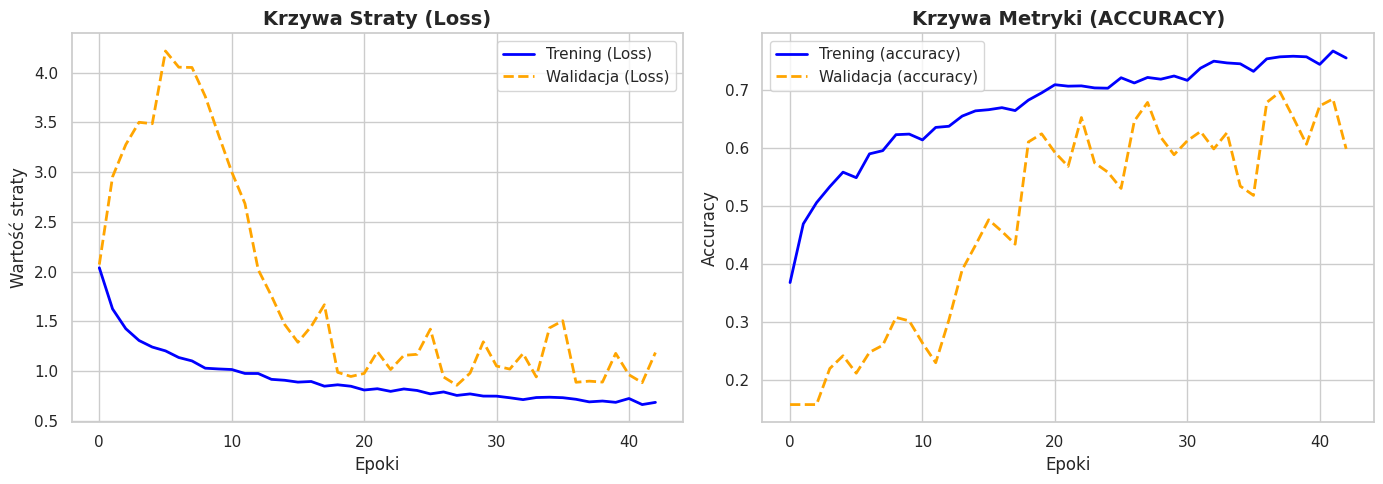

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


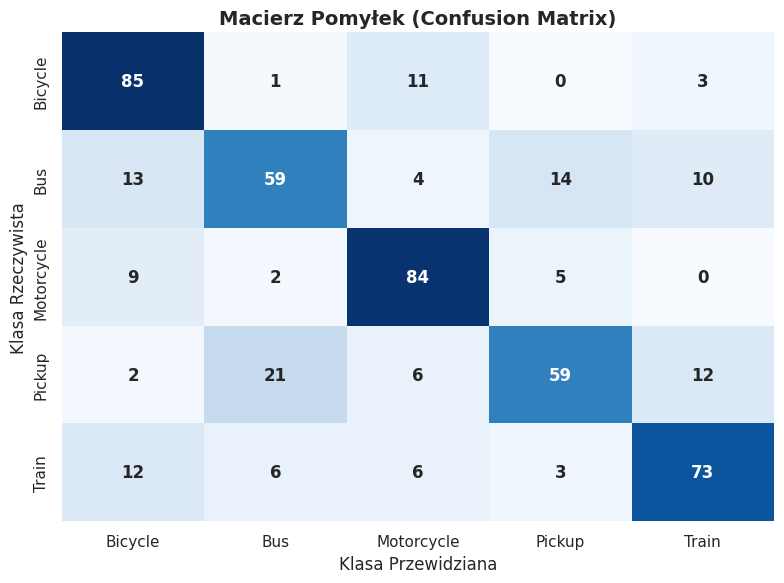


Raport Klasyfikacji (CNN):
              precision    recall  f1-score   support

     Bicycle       0.70      0.85      0.77       100
         Bus       0.66      0.59      0.62       100
  Motorcycle       0.76      0.84      0.80       100
      Pickup       0.73      0.59      0.65       100
       Train       0.74      0.73      0.74       100

    accuracy                           0.72       500
   macro avg       0.72      0.72      0.72       500
weighted avg       0.72      0.72      0.72       500



In [ ]:
print("--- WIZUALIZACJA LOSOWYCH ZDJĘĆ Z WYBRANYCH KLAS ---")
plt.figure(figsize=(15, 4))
for i, class_name in enumerate(class_names_c100):
    indices = np.where(y_train_c100 == i)[0]
    random_index = np.random.choice(indices)
    img = x_train_c100[random_index]
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Klasa: {class_name}\n(ID: {random_index})", fontsize=11)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("\n--- INICJALIZACJA ARCHITEKTURY I TRENINGU MODELU CNN ---")

l2_reg = regularizers.l2(1e-4)

model_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=l2_reg), 
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

early_stop_cnn = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_cnn = model_cnn.fit(x_train_c100, y_train_c100, 
                            epochs=100, 
                            batch_size=64,
                            validation_split=0.2,
                            callbacks=[early_stop_cnn],
                            verbose=1)

print("\n--- ANALIZA WYNIKÓW MODELU CNN ---")
plot_learning_curves(history_cnn, metric_name='accuracy')

y_pred_cnn = np.argmax(model_cnn.predict(x_test_c100), axis=-1)
plot_confusion_matrix(y_test_c100, y_pred_cnn, class_names_c100)

print("\nRaport Klasyfikacji (CNN):")
print(classification_report(y_test_c100, y_pred_cnn, target_names=class_names_c100))

ZADANIE 1: CIFAR-100 (CNN - Test Bez Early Stoppingu)


/home/uzytkownik/jupyter-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.3845 - loss: 2.0123 - val_accuracy: 0.2200 - val_loss: 2.0257
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.4660 - loss: 1.6000 - val_accuracy: 0.2200 - val_loss: 2.7631
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5010 - loss: 1.4336 - val_accuracy: 0.2200 - val_loss: 3.4345
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5465 - loss: 1.2446 - val_accuracy: 0.2200 - val_loss: 3.7439
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5500 - loss: 1.2070 - val_accuracy: 0.2240 - val_loss: 3.2587
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5750 - loss: 1.1546 - val_accuracy: 0.2420 - val_loss: 2.8575
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5980 - loss: 1.0928 - val_accuracy: 0.2680 - val_loss: 2.4985
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6025 - loss: 1.0517 - val_accuracy: 0.

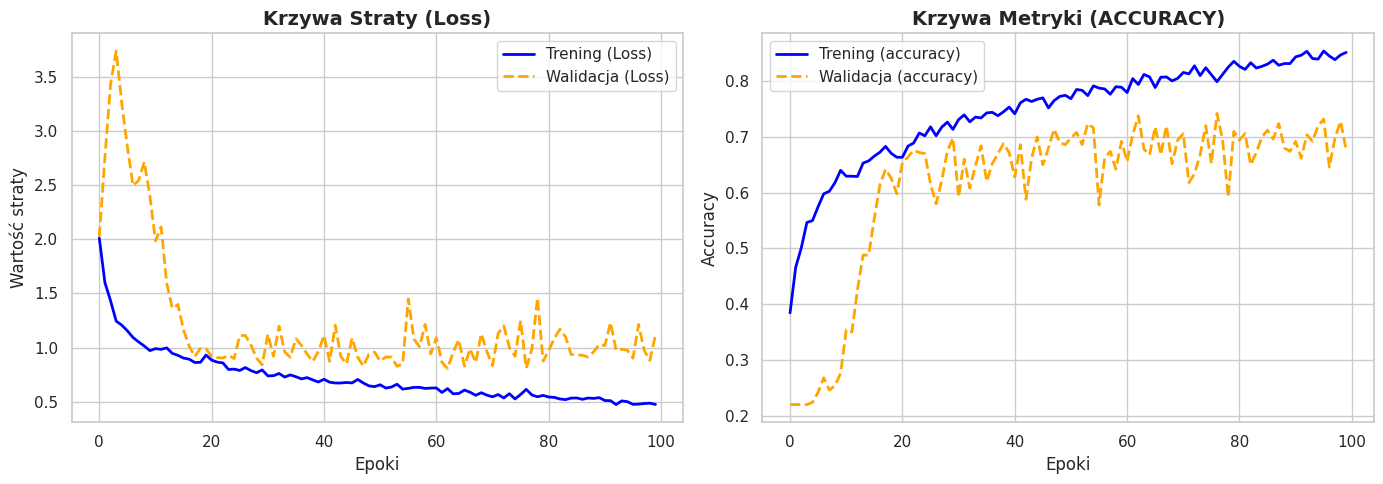

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


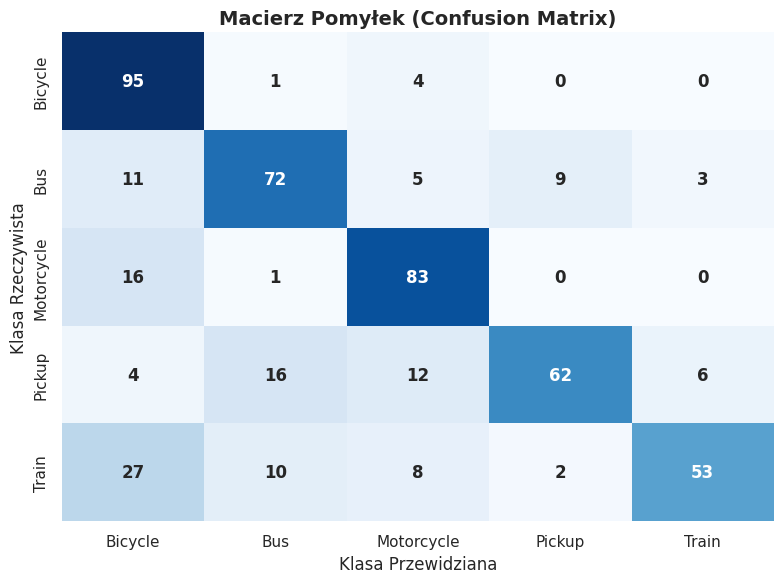

              precision    recall  f1-score   support

     Bicycle       0.62      0.95      0.75       100
         Bus       0.72      0.72      0.72       100
  Motorcycle       0.74      0.83      0.78       100
      Pickup       0.85      0.62      0.72       100
       Train       0.85      0.53      0.65       100

    accuracy                           0.73       500
   macro avg       0.76      0.73      0.73       500
weighted avg       0.76      0.73      0.73       500



In [ ]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar100.load_data()

selected_classes = [8, 13, 48, 58, 90]
class_names = ['Bicycle', 'Bus', 'Motorcycle', 'Pickup', 'Train']

train_mask = np.isin(y_train_full, selected_classes).flatten()
test_mask = np.isin(y_test_full, selected_classes).flatten()

x_train_c100 = x_train_full[train_mask].astype("float32") / 255.0
x_test_c100 = x_test_full[test_mask].astype("float32") / 255.0

mapping = {old_id: new_id for new_id, old_id in enumerate(selected_classes)}
y_train_c100 = np.array([mapping[cls] for cls in y_train_full[train_mask].flatten()])
y_test_c100 = np.array([mapping[cls] for cls in y_test_full[test_mask].flatten()])

l2_reg = regularizers.l2(1e-4)

model_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=l2_reg), 
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_cnn = model_cnn.fit(
    x_train_c100, y_train_c100, 
    epochs=100, 
    batch_size=64,
    validation_split=0.2,
    callbacks=[] 
)

print("\n[Wyniki dla CIFAR-100 - Bez Early Stoppingu]")
plot_learning_curves(history_cnn, metric_name='accuracy')

y_pred_cnn = np.argmax(model_cnn.predict(x_test_c100), axis=-1)
plot_confusion_matrix(y_test_c100, y_pred_cnn, class_names)

print(classification_report(y_test_c100, y_pred_cnn, target_names=class_names))

ZADANIE 2: WINE QUALITY (REGUŁA PERCEPTRONOWA Z EARLY STOPPING)

--- INICJALIZACJA I TRENING BAZOWEGO PERCEPTRONU (W2) ---
Status: Early Stopping aktywowany w epoce 20. Brak redukcji pomyłek przez 10 epok.

--- ANALIZA WYNIKÓW REGUŁY PERCEPTRONOWEJ ---


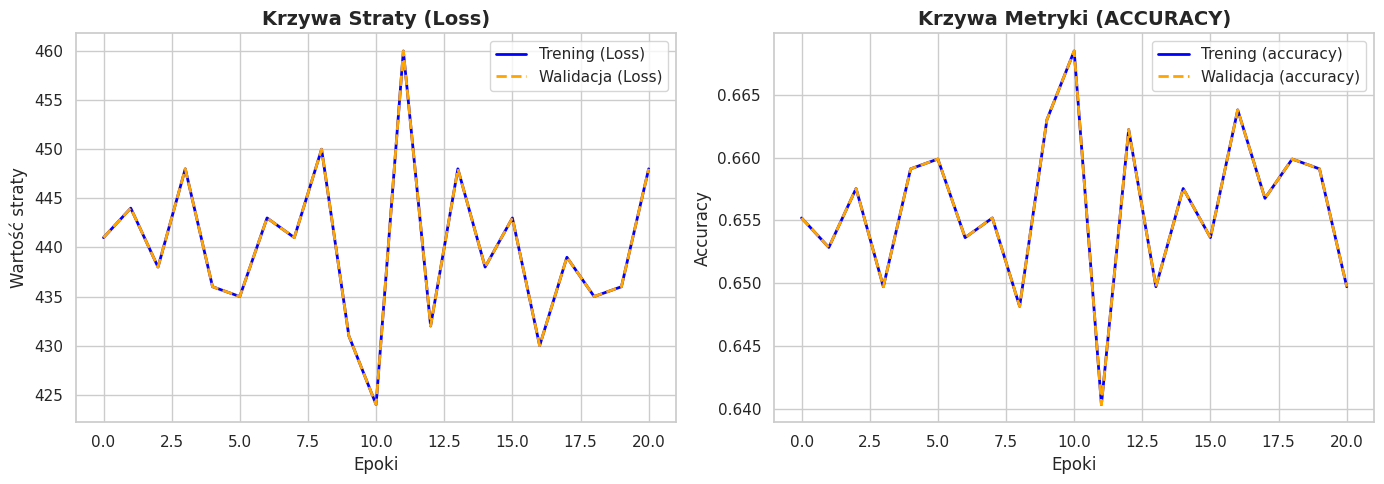

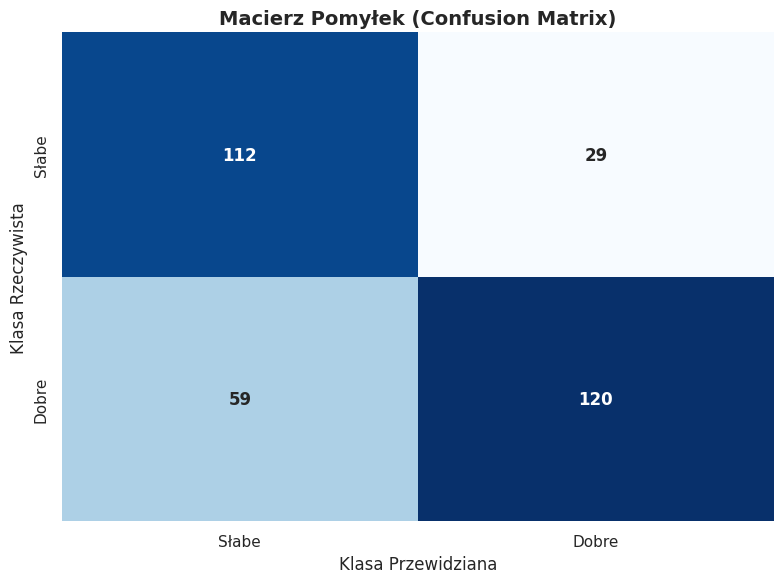


Raport Klasyfikacji (Perceptron Rosenblatta):
              precision    recall  f1-score   support

       Słabe       0.65      0.79      0.72       141
       Dobre       0.81      0.67      0.73       179

    accuracy                           0.72       320
   macro avg       0.73      0.73      0.72       320
weighted avg       0.74      0.72      0.73       320



In [ ]:
print("--- INICJALIZACJA I TRENING BAZOWEGO PERCEPTRONU (W2) ---")

X_train_b = np.hstack([np.ones((X_train_w.shape[0], 1)), X_train_w])
X_test_b = np.hstack([np.ones((X_test_w.shape[0], 1)), X_test_w])

y_train_mapped = np.where(y_train_w == 1, 1, -1)
y_test_mapped = np.where(y_test_w == 1, 1, -1)

lr_perc = 0.001
max_epochs = 100
patience_perc = 10
counter_perc = 0 
min_errors = float('inf')

weights_perc = np.zeros(X_train_b.shape[1])

history_perc = {'loss': [], 'accuracy': []}

for epoch in range(max_epochs):
    epoch_errors = 0
    
    for xi, target in zip(X_train_b, y_train_mapped):
        activation = 1 if np.dot(xi, weights_perc) >= 0 else -1
        
        if activation != target:
            weights_perc += lr_perc * target * xi
            epoch_errors += 1
            
    epoch_acc = 1 - (epoch_errors / len(X_train_b))
    history_perc['loss'].append(epoch_errors)
    history_perc['accuracy'].append(epoch_acc)
    
    if epoch_errors < min_errors:
        min_errors = epoch_errors
        counter_perc = 0  
    else:
        counter_perc += 1
        
    if counter_perc >= patience_perc:
        print(f"Status: Early Stopping aktywowany w epoce {epoch}. Brak redukcji pomyłek przez {patience_perc} epok.")
        break

print("\n--- ANALIZA WYNIKÓW REGUŁY PERCEPTRONOWEJ ---")

adapted_history = type('obj', (object,), {
    'history': {
        'loss': history_perc['loss'],
        'val_loss': history_perc['loss'],
        'accuracy': history_perc['accuracy'],
        'val_accuracy': history_perc['accuracy']
    }
})()

plot_learning_curves(adapted_history, metric_name='accuracy')

y_pred_perc = np.where(np.dot(X_test_b, weights_perc) >= 0, 1, -1)
plot_confusion_matrix(y_test_mapped, y_pred_perc, class_names=['Słabe', 'Dobre'])

print("\nRaport Klasyfikacji (Perceptron Rosenblatta):")
print(classification_report(y_test_mapped, y_pred_perc, target_names=['Słabe', 'Dobre']))

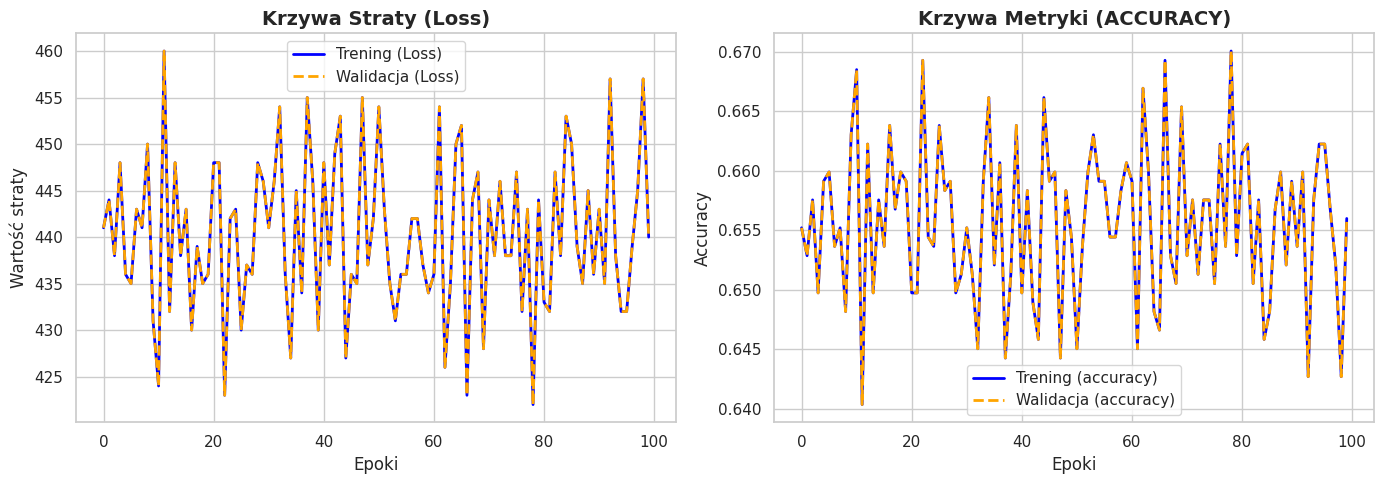

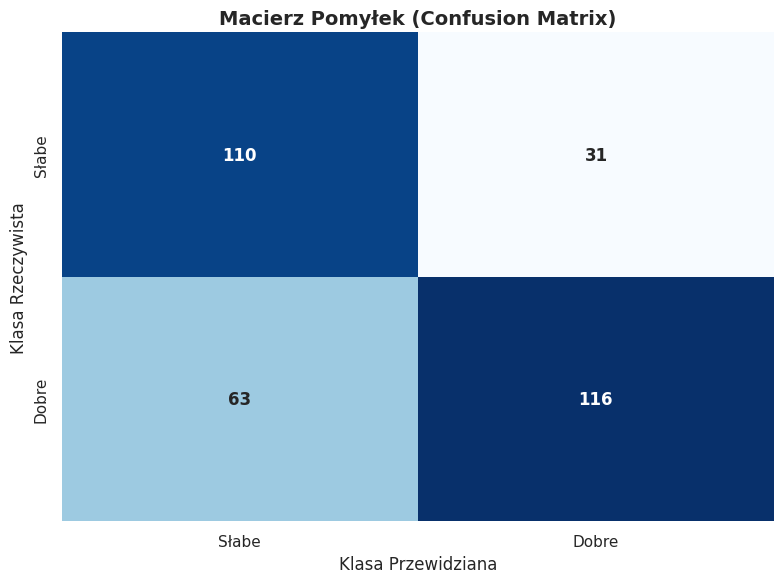

              precision    recall  f1-score   support

       Słabe       0.64      0.78      0.70       141
       Dobre       0.79      0.65      0.71       179

    accuracy                           0.71       320
   macro avg       0.71      0.71      0.71       320
weighted avg       0.72      0.71      0.71       320



In [ ]:
X_train_b = np.hstack([np.ones((X_train_w.shape[0], 1)), X_train_w])
X_test_b = np.hstack([np.ones((X_test_w.shape[0], 1)), X_test_w])
y_train_mapped = np.where(y_train_w == 1, 1, -1)
y_test_mapped = np.where(y_test_w == 1, 1, -1)

lr = 0.001
weights_perc = np.zeros(X_train_b.shape[1])
history_perc = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(100):
    epoch_errors = 0
    for xi, target in zip(X_train_b, y_train_mapped):
        activation = 1 if np.dot(xi, weights_perc) >= 0 else -1
        if activation != target:
            weights_perc += lr * target * xi
            epoch_errors += 1
            
    epoch_acc = 1 - (epoch_errors / len(X_train_b))
    history_perc['loss'].append(epoch_errors)
    history_perc['val_loss'].append(epoch_errors)
    history_perc['accuracy'].append(epoch_acc)
    history_perc['val_accuracy'].append(epoch_acc)

plot_learning_curves(type('obj', (object,), {'history': history_perc})(), metric_name='accuracy')
y_pred_perc = np.where(np.dot(X_test_b, weights_perc) >= 0, 1, -1)
plot_confusion_matrix(y_test_mapped, y_pred_perc, class_names=['Słabe', 'Dobre'])
print(classification_report(y_test_mapped, y_pred_perc, target_names=['Słabe', 'Dobre']))

ZADANIE 3: CALIFORNIA HOUSING (MULTI-LAYER PERCEPTRON FOR REGRESSION)


--- POBIERANIE I PRZETWARZANIE DANYCH GEOGRAFICZNO-EKONOMICZNYCH ---

--- BUDOWA ARCHITEKTURY SIECI DLA ZADANIA REGRESJI ---
Epoch 1/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0745 - mae: 0.7074 - val_loss: 0.4840 - val_mae: 0.5030 - learning_rate: 0.0010
Epoch 2/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4022 - mae: 0.4508 - val_loss: 0.4042 - val_mae: 0.4483 - learning_rate: 0.0010
Epoch 3/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3622 - mae: 0.4266 - val_loss: 0.3747 - val_mae: 0.4266 - learning_rate: 0.0010
Epoch 4/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3441 - mae: 0.4143 - val_loss: 0.3799 - val_mae: 0.4232 - learning_rate: 0.0010
Epoch 5/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3355 - mae: 0.4060 - val_loss: 0.3506 - val_mae: 0.4117 - learning_rate: 0.0010
Epoch 6/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3216 - mae: 0.3973 - val_loss: 0.3483 - val_mae: 0.4047 - learning_rate: 0.0010
Epoch 7/40
207/207 ━━━━

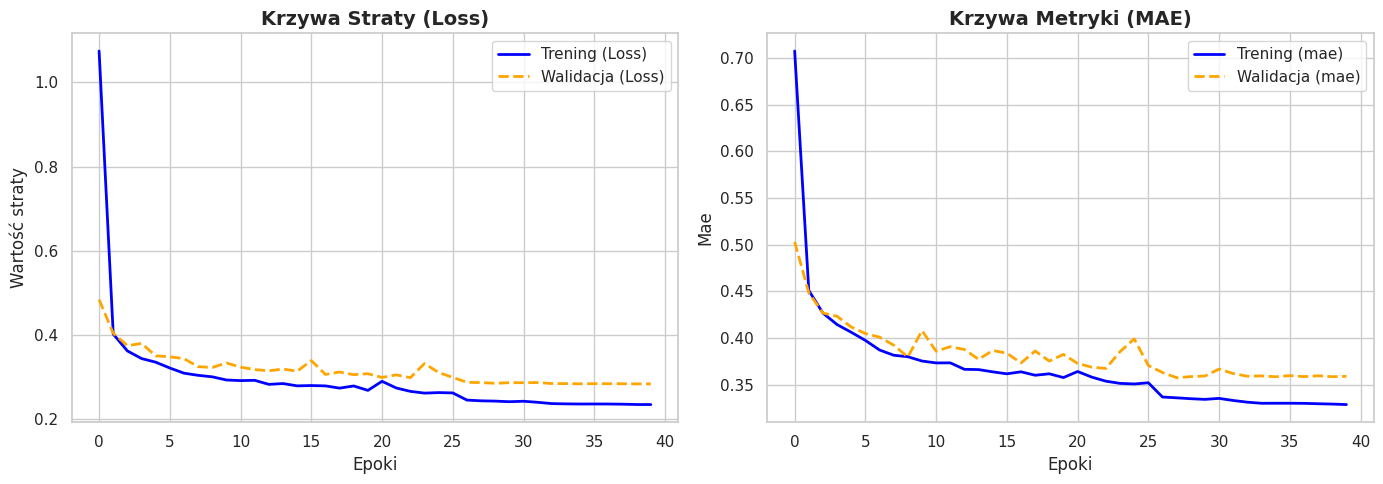

Ostateczny błąd testowy MSE (Loss): 0.2723
Ostateczny błąd testowy MAE (Średni błąd w setkach tys. $): 0.3519
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step


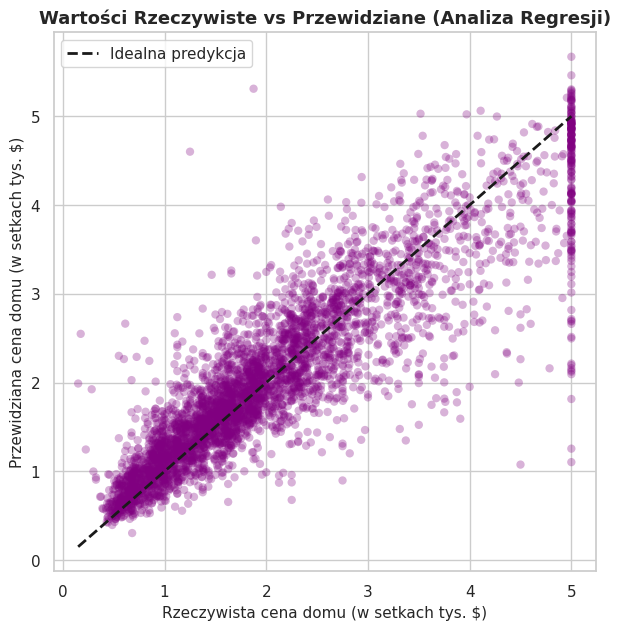

In [ ]:
print("--- POBIERANIE I PRZETWARZANIE DANYCH GEOGRAFICZNO-EKONOMICZNYCH ---")
housing = fetch_california_housing()
X_house, y_house = housing.data, housing.target

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

scaler_house = StandardScaler()
X_train_h = scaler_house.fit_transform(X_train_h)
X_test_h = scaler_house.transform(X_test_h)

print("\n--- BUDOWA ARCHITEKTURY SIECI DLA ZADANIA REGRESJI ---")
model_mlp_reg = models.Sequential([
    layers.Input(shape=(X_train_h.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model_mlp_reg.compile(optimizer='adam', 
                      loss='mse', 
                      metrics=['mae'])

reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)

history_house = model_mlp_reg.fit(X_train_h, y_train_h, 
                                  epochs=40, 
                                  batch_size=64,
                                  validation_split=0.2, 
                                  callbacks=[reduce_lr], 
                                  verbose=1)

print("\n--- DIAGNOSTYKA I ANALIZA GEOMETRYCZNA BŁĘDU REGRESJI ---")
plot_learning_curves(history_house, metric_name='mae')

test_loss, test_mae = model_mlp_reg.evaluate(X_test_h, y_test_h, verbose=0)
print(f"Ostateczny błąd testowy MSE (Loss): {test_loss:.4f}")
print(f"Ostateczny błąd testowy MAE (Średni błąd w setkach tys. $): {test_mae:.4f}")

y_pred_house = model_mlp_reg.predict(X_test_h).flatten()

plt.figure(figsize=(7, 7))
plt.scatter(y_test_h, y_pred_house, alpha=0.3, color='purple', edgecolors='none')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'k--', lw=2, label='Idealna predykcja')
plt.title('Wartości Rzeczywiste vs Przewidziane (Analiza Regresji)', fontsize=13, fontweight='bold')
plt.xlabel('Rzeczywista cena domu (w setkach tys. $)', fontsize=11)
plt.ylabel('Przewidziana cena domu (w setkach tys. $)', fontsize=11)
plt.legend()
plt.grid(True)
plt.show()